
Dataset Shape:
(14, 5)

First Rows:
         Country           GDP  GDP_PER_CAPITA  INFLATION  UNEMPLOYMENT
0  United States  2.875096e+13    84534.040784   2.949525         4.198
1          China  1.874380e+13    13303.148154   0.218129         4.615
2          India  3.909892e+12     2694.737809   4.953036         4.219
3          Japan  4.027598e+12    32487.077805   2.738537         2.451
4        Germany  4.685593e+12    56103.732318   2.256498         3.711


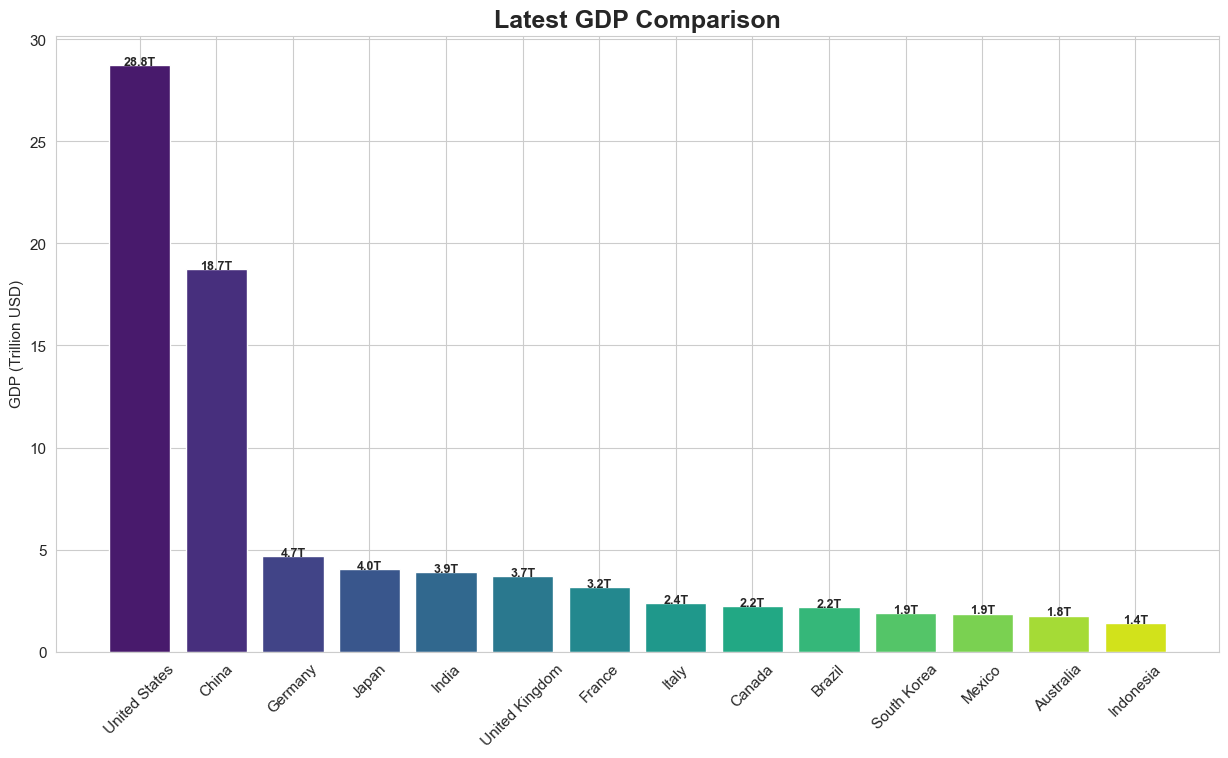

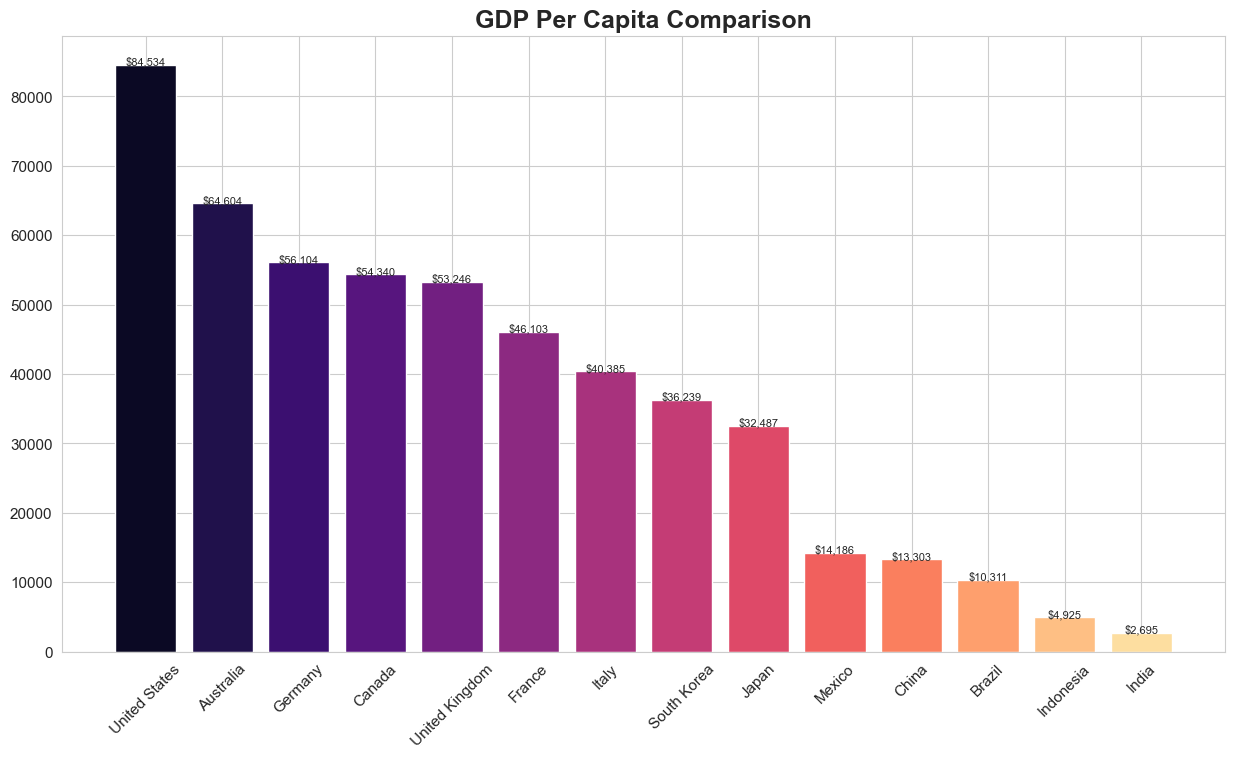

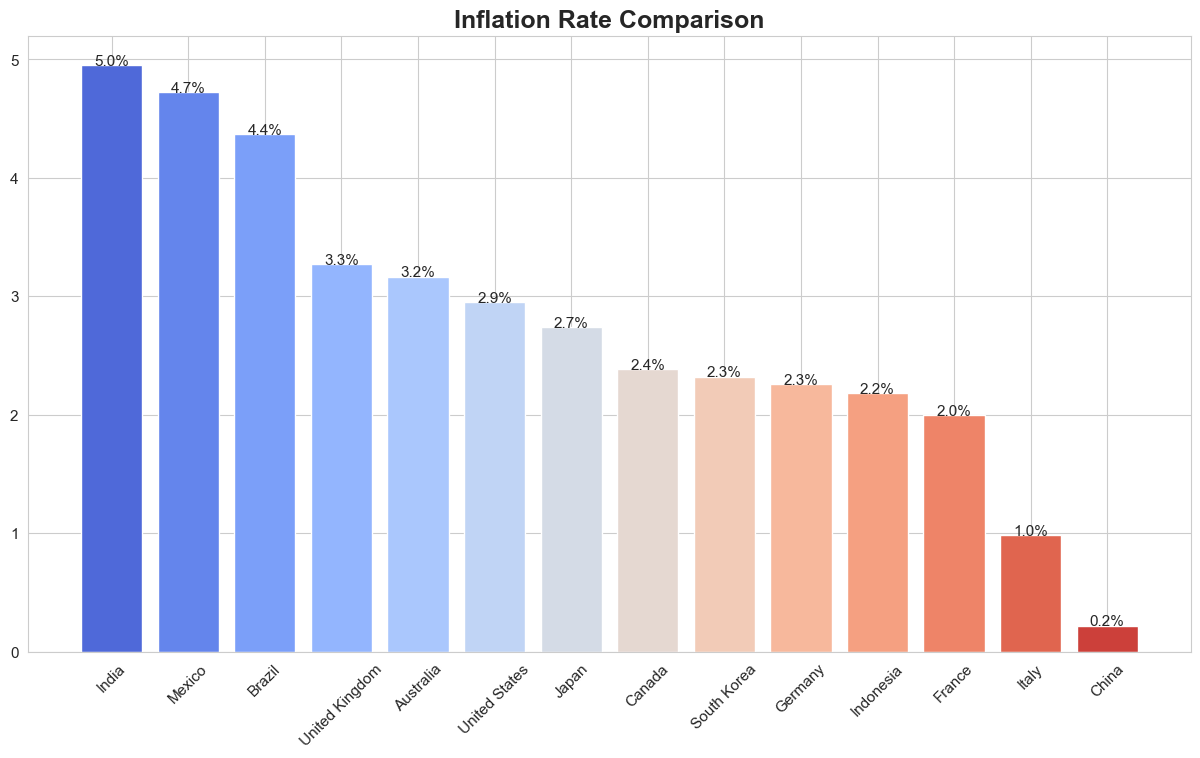

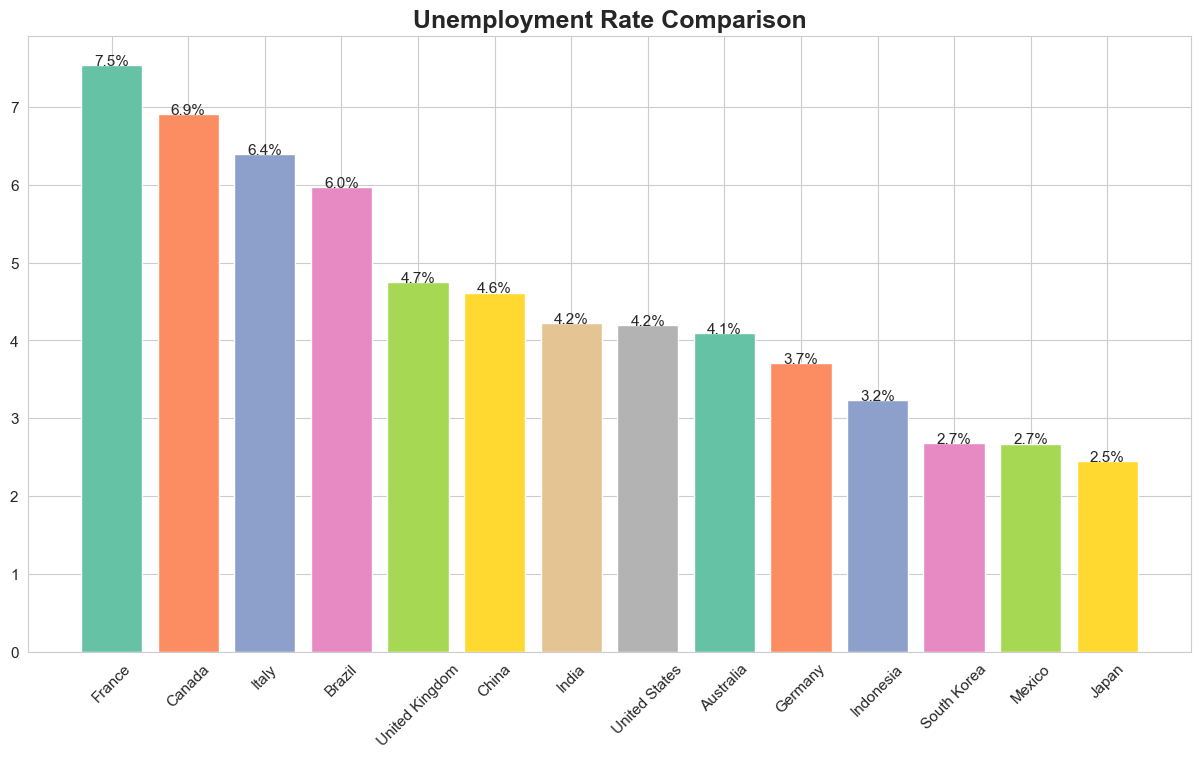

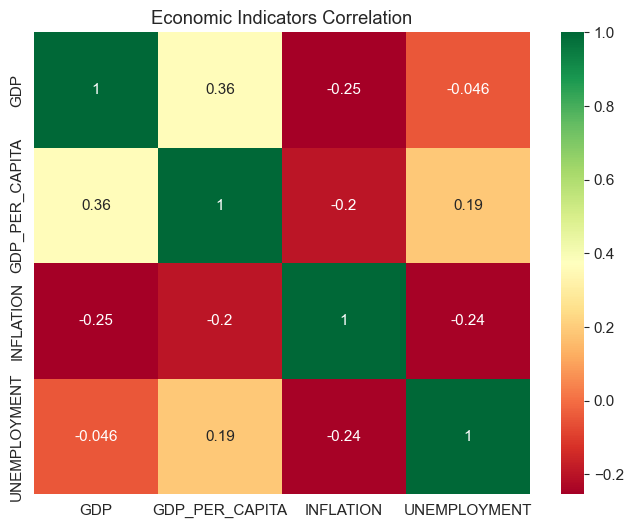

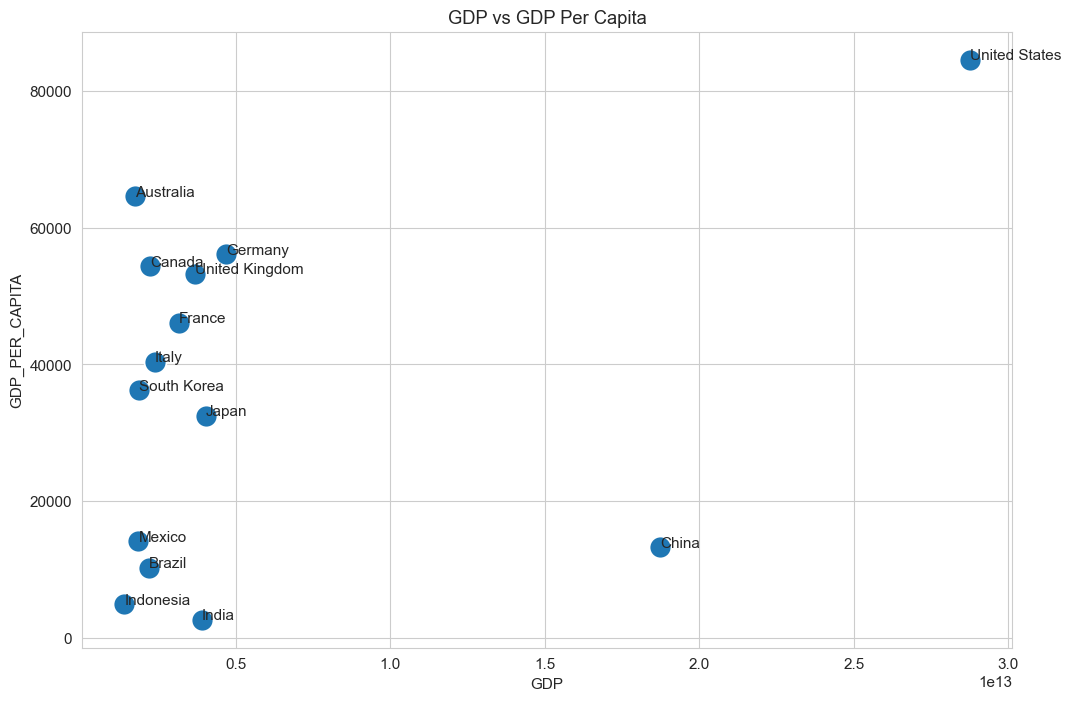


Highest GDP:
United States

Highest GDP Per Capita:
United States

Highest Inflation:
India

Highest Unemployment:
France


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.rcParams['figure.figsize'] = (14,8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Countries
countries = {
    "US":"United States",
    "CN":"China",
    "IN":"India",
    "JP":"Japan",
    "DE":"Germany",
    "GB":"United Kingdom",
    "FR":"France",
    "IT":"Italy",
    "CA":"Canada",
    "BR":"Brazil",
    "KR":"South Korea",
    "AU":"Australia",
    "MX":"Mexico",
    "ID":"Indonesia"
}

# World Bank Indicators
indicators = {
    "GDP":"NY.GDP.MKTP.CD",
    "GDP_PER_CAPITA":"NY.GDP.PCAP.CD",
    "INFLATION":"FP.CPI.TOTL.ZG",
    "UNEMPLOYMENT":"SL.UEM.TOTL.ZS"
}

# ----------------------------------
# Download Data
# ----------------------------------

all_data = []

headers = {
    "User-Agent": "Mozilla/5.0"
}

for country_code, country_name in countries.items():

    row = {"Country": country_name}

    for metric, indicator in indicators.items():

        url = (
            f"https://api.worldbank.org/v2/country/"
            f"{country_code}/indicator/{indicator}"
            f"?format=json&per_page=100"
        )

        try:

            response = requests.get(
                url,
                headers=headers,
                timeout=30
            ).json()

            latest_value = np.nan

            if isinstance(response, list) and len(response) > 1:

                for item in response[1]:

                    if item["value"] is not None:

                        latest_value = item["value"]
                        break

            row[metric] = latest_value

        except Exception as e:

            print("Error:", country_name, metric)
            row[metric] = np.nan

    all_data.append(row)

# Create DataFrame
df = pd.DataFrame(all_data)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst Rows:")
print(df.head())

# ----------------------------------
# GDP Ranking
# ----------------------------------

gdp_df = df.sort_values(
    "GDP",
    ascending=False
)

plt.figure(figsize=(15,8))

colors = sns.color_palette(
    "viridis",
    len(gdp_df)
)

bars = plt.bar(
    gdp_df["Country"],
    gdp_df["GDP"]/1e12,
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}T",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    "Latest GDP Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.ylabel("GDP (Trillion USD)")
plt.xticks(rotation=45)

plt.show()

# ----------------------------------
# GDP Per Capita
# ----------------------------------

pc_df = df.sort_values(
    "GDP_PER_CAPITA",
    ascending=False
)

plt.figure(figsize=(15,8))

colors = sns.color_palette(
    "magma",
    len(pc_df)
)

bars = plt.bar(
    pc_df["Country"],
    pc_df["GDP_PER_CAPITA"],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha='center',
        fontsize=8
    )

plt.title(
    "GDP Per Capita Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.show()

# ----------------------------------
# Inflation Rate
# ----------------------------------

inflation_df = df.sort_values(
    "INFLATION",
    ascending=False
)

plt.figure(figsize=(15,8))

colors = sns.color_palette(
    "coolwarm",
    len(inflation_df)
)

bars = plt.bar(
    inflation_df["Country"],
    inflation_df["INFLATION"],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center'
    )

plt.title(
    "Inflation Rate Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.show()

# ----------------------------------
# Unemployment
# ----------------------------------

unemp_df = df.sort_values(
    "UNEMPLOYMENT",
    ascending=False
)

plt.figure(figsize=(15,8))

colors = sns.color_palette(
    "Set2",
    len(unemp_df)
)

bars = plt.bar(
    unemp_df["Country"],
    unemp_df["UNEMPLOYMENT"],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center'
    )

plt.title(
    "Unemployment Rate Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.show()

# ----------------------------------
# Correlation Heatmap
# ----------------------------------

plt.figure(figsize=(8,6))

corr = df.drop(
    columns=["Country"]
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn"
)

plt.title(
    "Economic Indicators Correlation"
)

plt.show()

# ----------------------------------
# GDP vs Per Capita
# ----------------------------------

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="GDP",
    y="GDP_PER_CAPITA",
    s=250
)

for _, row in df.iterrows():

    plt.text(
        row["GDP"],
        row["GDP_PER_CAPITA"],
        row["Country"]
    )

plt.title(
    "GDP vs GDP Per Capita"
)

plt.show()

# ----------------------------------
# Summary
# ----------------------------------

print("\nHighest GDP:")
print(df.loc[df["GDP"].idxmax(), "Country"])

print("\nHighest GDP Per Capita:")
print(df.loc[df["GDP_PER_CAPITA"].idxmax(), "Country"])

print("\nHighest Inflation:")
print(df.loc[df["INFLATION"].idxmax(), "Country"])

print("\nHighest Unemployment:")
print(df.loc[df["UNEMPLOYMENT"].idxmax(), "Country"])